<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# A Neural Network From Scratch

[Notebook 01](01_Tensors_And_Autograd.ipynb) fitted a polynomial with four weights.
Now a real task: **recognising handwritten digits**, using nothing but tensors and
autograd.

No `torch.nn`, no layers, no optimizer, no data loader. Every piece is written out,
which is the only way to see what those pieces do when we start using them in
[notebook 03](03_Refactoring_With_torch_nn.ipynb).

---

## Contents

1. [The data](#data)
2. [Weights and biases](#weights)
3. [The forward pass](#forward)
4. [Working in batches](#batches)
5. [Loss and accuracy](#loss)
6. [The training loop](#train)
7. [Making a prediction](#predict)

<a id="data"></a>
## 1. The data

**MNIST**: 28 × 28 greyscale images of handwritten digits, each labelled with the
number it shows. The file `mnist.pkl.gz` sits next to this notebook and holds a
training set, a validation set and a test set.

Each image arrives **flattened** — one row of 784 numbers rather than a 28 × 28
square — which suits us, because the network we are about to build wants a flat row
anyway.

In [1]:
import gzip
import pickle

import torch

with gzip.open("mnist.pkl.gz", "rb") as file:
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(file, encoding="latin-1")

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)

n, c = x_train.shape
print("training images:", tuple(x_train.shape))

training images: (50000, 784)


`map(torch.tensor, ...)` converts all four arrays at once: PyTorch works with
tensors, and the file contains NumPy arrays.

To look at an image we have to fold the 784 numbers back into a square.

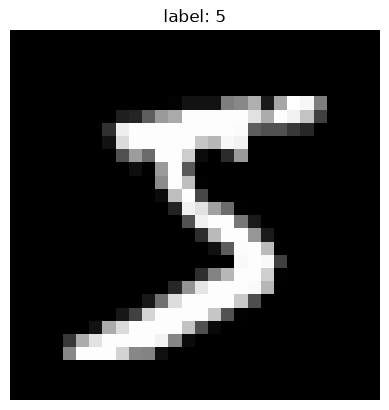

In [2]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0].reshape((28, 28)), cmap="gray")
plt.title(f"label: {y_train[0]}")
plt.axis("off")
plt.show()

In [3]:
print("pixel range: ", x_train.min().item(), "to", x_train.max().item())
print("labels:      ", y_train.min().item(), "to", y_train.max().item())

pixel range:  0.0 to 0.99609375
labels:       0 to 9


<a id="weights"></a>
## 2. Weights and biases

The model is as simple as a classifier can be: **784 inputs straight to 10 outputs**,
one output per digit, with nothing in between.

![The network we build from scratch](../../images/pt_mnist_logistic.svg)

That needs a 784 × 10 matrix of weights plus 10 biases — 7,850 numbers in total.

Two details:

- the weights are divided by `sqrt(784)`. Starting values that are too large make
  training unstable, and this is a standard way of scaling them to the number of
  inputs
- **`requires_grad`** marks both tensors as things autograd should track. The
  trailing underscore in `requires_grad_()` is PyTorch's convention for *modify this
  object in place*

In [4]:
import math

weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()

bias = torch.zeros(10, requires_grad=True)

print("weights:", tuple(weights.shape))
print("bias:   ", tuple(bias.shape))

weights: (784, 10)
bias:    (10,)


<a id="forward"></a>
## 3. The forward pass

Two functions, and they are the whole model.

`model` multiplies the input by the weights and adds the bias. The **`@`** is
Python's matrix-multiplication operator: a batch of shape `K × 784` times a
`784 × 10` matrix gives `K × 10` — one score per digit, for each of the K images.

`log_softmax` turns those raw scores into log-probabilities, so that the ten numbers
for an image can be compared as *how likely is each digit*.

In [5]:
def log_softmax(x):
    return x - x.exp().sum(-1).log().unsqueeze(-1)


def model(xb):
    return log_softmax(xb @ weights + bias)

<a id="batches"></a>
## 4. Working in batches

The network does not see one image at a time. It sees a **batch** of them, exactly
as in the TensorFlow notebooks — matrix operations parallelise well, and hardware is
built for doing many at once.

Here is one batch of 64 images pushed through the untrained model.

In [6]:
bs = 64          # batch size

xb = x_train[0:bs]
preds = model(xb)

print("batch shape:      ", tuple(xb.shape))
print("prediction shape: ", tuple(preds.shape))
print("\nscores for the first image:")
print(preds[0])

batch shape:       (64, 784)
prediction shape:  (64, 10)

scores for the first image:
tensor([-2.4115, -2.4290, -1.9187, -2.5874, -2.2910, -2.3958, -2.4047, -2.3241,
        -2.6181, -1.9186], grad_fn=<SelectBackward0>)


Ten numbers for the first image, one per digit — and a `grad_fn`, because autograd
is already recording. The values are meaningless so far; the weights are random.

<a id="loss"></a>
## 5. Loss and accuracy

The loss function is **negative log-likelihood**: for each image, take the score the
model gave to the *correct* digit, and average those over the batch. Since the scores
are log-probabilities, a confident correct answer is near 0 and a confident wrong one
is a large negative number — so negating gives something to minimise.

In [7]:
def nll(input, target):
    return -input[range(target.shape[0]), target].mean()


loss_func = nll

yb = y_train[0:bs]
initial_loss = loss_func(preds, yb)
print("loss before training:", initial_loss.item())

loss before training: 2.318446397781372


Accuracy is easier to read than loss, so we track it too: for each image take the
digit with the highest score, and count how often that matches the label.

In [8]:
def accuracy(out, yb):
    preds = torch.argmax(out, dim=1)
    return (preds == yb).float().mean()


initial_accuracy = accuracy(preds, yb)
print("accuracy before training:", initial_accuracy.item())

accuracy before training: 0.0625


About one in ten, which is what random guessing between ten digits should give.

<a id="train"></a>
## 6. The training loop

Everything is in place. For each batch:

1. take a slice of the training data
2. run the forward pass and compute the loss
3. call `loss.backward()` to fill in the gradients
4. step the weights downhill and clear the gradients

The update sits inside `torch.no_grad()` for the reason given in notebook 01 —
adjusting the weights is bookkeeping, not part of the next gradient calculation.

In [9]:
lr = 0.5         # learning rate
epochs = 2

for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
        start_i = i * bs
        end_i = start_i + bs
        xb = x_train[start_i:end_i]
        yb = y_train[start_i:end_i]

        pred = model(xb)
        loss = loss_func(pred, yb)

        loss.backward()

        with torch.no_grad():
            weights -= weights.grad * lr
            bias -= bias.grad * lr
            weights.grad.zero_()
            bias.grad.zero_()

    print(f"epoch {epoch + 1} finished")

epoch 1 finished
epoch 2 finished


That is a complete neural network, trained from scratch. Strictly it is a *logistic
regression*, since there are no hidden layers — but the machinery is identical to any
larger network's.

The comparison below is on the **last training batch**, so treat the accuracy figure
with suspicion — those are 64 images the model has just been fitted to, and a perfect
score on them means very little. Measuring properly needs data the model has not
seen, which is what the validation set in
[notebook 03](03_Refactoring_With_torch_nn.ipynb) is for.

In [10]:
print(f"loss:     {initial_loss:.5f}  ->  {loss_func(model(xb), yb):.5f}")
print(f"accuracy: {initial_accuracy:.5f}  ->  {accuracy(model(xb), yb):.5f}")

loss:     2.31845  ->  0.08227
accuracy: 0.06250  ->  1.00000


<a id="predict"></a>
## 7. Making a prediction

Finally, one image from the **validation** set — data the model has not been trained
on.

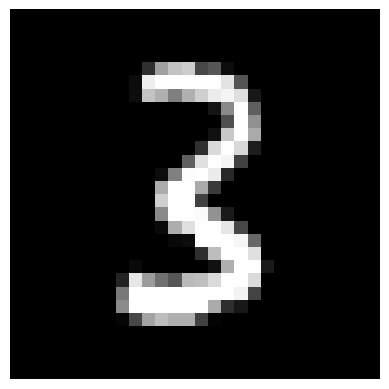

predicted: 3   actual: 3


In [11]:
test_img = x_valid[0]
test_label = y_valid[0]

prediction = torch.argmax(model(test_img))

plt.imshow(test_img.reshape((28, 28)), cmap="gray")
plt.axis("off")
plt.show()

print(f"predicted: {prediction.item()}   actual: {test_label.item()}")

It works — but look back at how much code it took. Roughly fifty lines, several of
which are easy to get wrong in silence: forgetting to zero the gradients, slicing the
batches by hand, remembering `no_grad()`.

[Notebook 03](03_Refactoring_With_torch_nn.ipynb) removes them one at a time.